<a href="https://colab.research.google.com/github/ikhyun00/project/blob/main/kaggle_%EC%8B%9C%ED%97%98%EC%A0%90%EC%88%98%EC%98%88%EC%B8%A1_SHAP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb


In [ ]:
# ✅ 당신이 쓰는 데이터 로드 방식 그대로
DATA_PATH = '/content/drive/MyDrive/멀티캠퍼스/4_머신러닝_딥러닝/프로젝트 회귀/'

train_df = pd.read_csv(DATA_PATH + 'data/train.csv')
test_df  = pd.read_csv(DATA_PATH + 'data/test.csv')

TARGET = "exam_score"
RANDOM_STATE = 42
N_SPLITS = 5

print(train_df.shape, test_df.shape)
display(train_df.head())


(630000, 13) (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [ ]:
# sanity check
assert TARGET in train_df.columns, f"TARGET='{TARGET}' not in train columns: {list(train_df.columns)}"


In [ ]:
# Split X/y
X = train_df.drop(columns=[TARGET], errors="ignore").drop(columns=["id"], errors="ignore")
y = train_df[TARGET].copy()

X_test = test_df.drop(columns=["id"], errors="ignore")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("num_cols:", len(num_cols), "| cat_cols:", len(cat_cols))


num_cols: 4 | cat_cols: 7


In [ ]:
# Preprocessing (Ridge vs Tree)
numeric_prep_ridge = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

numeric_prep_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])

categorical_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_ridge = ColumnTransformer(
    transformers=[
        ("num", numeric_prep_ridge, num_cols),
        ("cat", categorical_prep, cat_cols),
    ],
    remainder="drop",
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_prep_tree, num_cols),
        ("cat", categorical_prep, cat_cols),
    ],
    remainder="drop",
)

def build_pipe(name: str, model):
    prep = preprocess_ridge if name.lower().startswith("ridge") else preprocess_tree
    return Pipeline(steps=[("prep", prep), ("model", model)])


In [ ]:
# Models (safe but strong defaults)
models = {
    "Ridge": Ridge(alpha=3.0, random_state=RANDOM_STATE),

    "HGBR": HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=None,
        max_leaf_nodes=63,
        min_samples_leaf=20,
        l2_regularization=0.0,
        max_iter=900,
        random_state=RANDOM_STATE
    ),

    "XGB": xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=5,
        gamma=0.0,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
}

pipes = {name: build_pipe(name, model) for name, model in models.items()}
pipes


{'Ridge': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(add_indicator=True,
                                                                                  strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'study_hours',
                                                    'class_attendance',
                                                    'sleep_hours']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequen

In [ ]:
def rmse_cv(pipe, X, y, n_splits=5):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        pipe, X, y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    rmse = -scores
    return rmse.mean(), rmse.std()

def oof_pred(pipe, X, y, n_splits=5):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X), dtype=float)
    for tr_idx, va_idx in cv.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y.iloc[tr_idx]
        p = clone(pipe)
        p.fit(X_tr, y_tr)
        oof[va_idx] = p.predict(X_va)
    return oof

print("[CV RMSE]")
for name, pipe in pipes.items():
    m, s = rmse_cv(pipe, X, y, n_splits=N_SPLITS)
    print(f"{name}: {m:.5f} (std {s:.5f})")


[CV RMSE]
Ridge: 8.89482 (std 0.01008)
HGBR: 8.77588 (std 0.00938)
XGB: 8.77910 (std 0.01245)


In [ ]:
# OOF predictions + blending weights search
print("\n[OOF RMSE]")
oof_preds = {}
for name, pipe in pipes.items():
    pred = oof_pred(pipe, X, y, n_splits=N_SPLITS)
    rmse = np.sqrt(mean_squared_error(y, pred))   # ✅ 변경
    oof_preds[name] = pred
    print(f"{name}: {rmse:.5f}")

a = oof_preds["Ridge"]
b = oof_preds["HGBR"]
c = oof_preds["XGB"]

best_rmse, best_w = 1e18, (1/3, 1/3, 1/3)
grid = np.linspace(0, 1, 21)

for w1 in grid:
    for w2 in grid:
        if w1 + w2 > 1:
            continue
        w3 = 1 - (w1 + w2)
        blend = w1 * a + w2 * b + w3 * c
        rmse = np.sqrt(mean_squared_error(y, blend))  # ✅ 변경
        if rmse < best_rmse:
            best_rmse, best_w = rmse, (w1, w2, w3)

w1, w2, w3 = best_w
print(f"\n[Best Blend] Ridge*{w1:.2f} + HGBR*{w2:.2f} + XGB*{w3:.2f} => RMSE {best_rmse:.5f}")


[OOF RMSE]
Ridge: 8.89482
HGBR: 8.77588
XGB: 8.77911

[Best Blend] Ridge*0.00 + HGBR*0.55 + XGB*0.45 => RMSE 8.76852


In [ ]:
# Fit full data + predict test + save submission
for name in ["Ridge", "HGBR", "XGB"]:
    pipes[name].fit(X, y)

pred_test = (
    w1 * pipes["Ridge"].predict(X_test)
    + w2 * pipes["HGBR"].predict(X_test)
    + w3 * pipes["XGB"].predict(X_test)
)

# Optional: clip to train target range (bounded scores에서 종종 도움)
pred_test = np.clip(pred_test, float(y.min()), float(y.max()))

# IMPORTANT: Do NOT round (rounding typically hurts RMSE)
id_col = "id" if "id" in test_df.columns else test_df.columns[0]
sub = pd.DataFrame({id_col: test_df[id_col], TARGET: pred_test})

out_path = Path("submission_blend.csv")
sub.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())
display(sub.head())


Saved: /content/submission_blend.csv


,id,exam_score
0,630000,72.320272
1,630001,69.789030
2,630002,88.004862
3,630003,56.254773
4,630004,47.135671


## 🔎 모델이 실제로 많이 쓴 변수 확인 (Permutation Importance / SHAP)

- **Permutation importance**: 검증셋에서 특정 변수를 섞었을 때 RMSE가 얼마나 나빠지는지로 중요도를 측정.  

- **SHAP(XGB)**: 예측값을 각 변수 기여도로 분해해, 어떤 변수가 점수를 올리거나 내리는지(방향 포함)를 시각화.

[Holdout] train=504,000, valid=5,000

[Ridge] holdout RMSE = 8.8818


,feature,importance,std
3,study_hours,11.947094,0.126930
4,class_attendance,2.874484,0.071711
7,sleep_quality,1.376420,0.042715
8,study_method,1.162104,0.050449
9,facility_rating,0.930540,0.041335
6,sleep_hours,0.579805,0.034812
1,gender,0.000987,0.002074
0,age,0.000153,0.000339
2,course,0.000127,0.001054
10,exam_difficulty,0.000090,0.000240



[HGBR] holdout RMSE = 8.7795


,feature,importance,std
3,study_hours,12.078236,0.135801
4,class_attendance,2.941939,0.064080
7,sleep_quality,1.384318,0.047947
8,study_method,1.169032,0.050418
9,facility_rating,0.938517,0.038757
6,sleep_hours,0.609653,0.039220
0,age,0.011836,0.003663
2,course,0.009042,0.002811
1,gender,0.002240,0.002676
10,exam_difficulty,0.000698,0.001198



[XGB] holdout RMSE = 8.7702


,feature,importance,std
3,study_hours,12.075277,0.132227
4,class_attendance,2.932503,0.064990
7,sleep_quality,1.388095,0.045338
8,study_method,1.167534,0.050591
9,facility_rating,0.938292,0.040765
6,sleep_hours,0.601603,0.037427
0,age,0.008039,0.003299
2,course,0.004583,0.002775
1,gender,0.001172,0.002009
10,exam_difficulty,-0.000048,0.000756


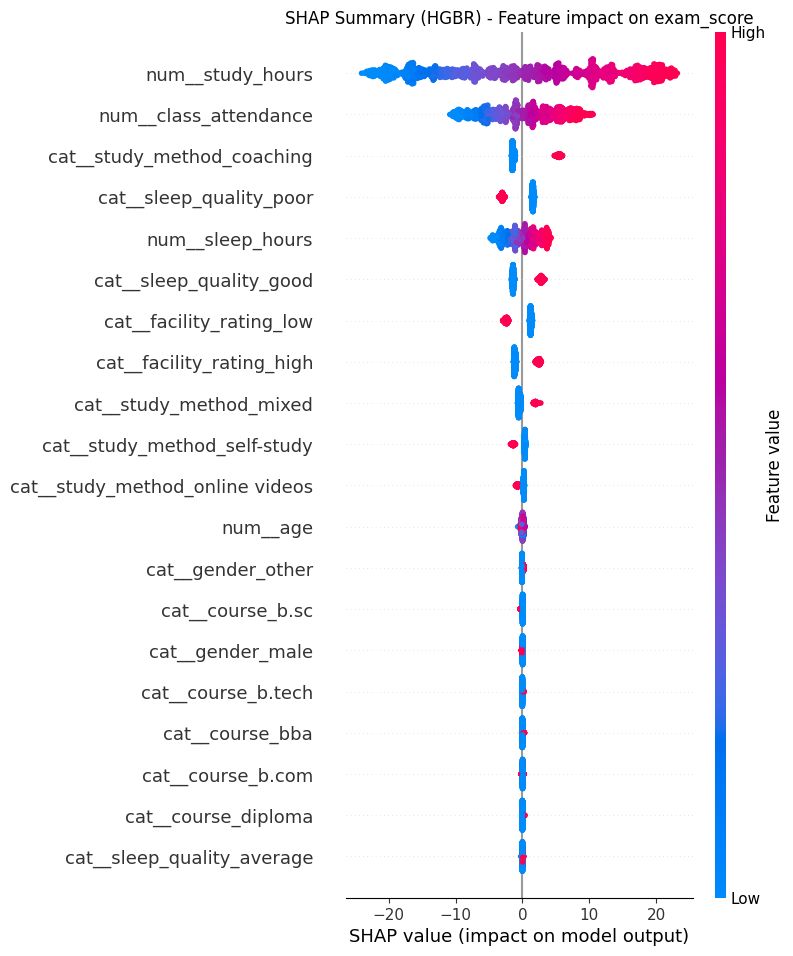

In [ ]:
# =========================
# Feature Importance: Permutation + SHAP (버전 호환 수정)
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.base import clone

RANDOM_STATE = 42

# 1) 학습/검증 분리(중요도 계산은 y_true가 필요)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# (선택) 속도 최적화: 검증 샘플을 일부만 사용
VAL_N = min(5000, len(X_val))
X_val_s = X_val.sample(n=VAL_N, random_state=RANDOM_STATE)
y_val_s = y_val.loc[X_val_s.index]

print(f"[Holdout] train={len(X_tr):,}, valid={len(X_val_s):,}")

# ✅ RMSE 직접 계산(버전 호환)
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ✅ permutation_importance용 neg-RMSE scorer(버전 호환)
def neg_rmse(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))

neg_rmse_scorer = make_scorer(neg_rmse, greater_is_better=True)

def show_perm_importance(pipe, model_name, topk=20):
    est = clone(pipe)
    est.fit(X_tr, y_tr)

    pred = est.predict(X_val_s)
    holdout_rmse = rmse(y_val_s, pred)
    print(f"\n[{model_name}] holdout RMSE = {holdout_rmse:.4f}")

    perm = permutation_importance(
        est, X_val_s, y_val_s,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring=neg_rmse_scorer,  # ✅ 커스텀 scorer 사용
        n_jobs=-1
    )

    imp_df = pd.DataFrame({
        "feature": X_val_s.columns,           # 원본 컬럼 기준(네 목적에 맞음)
        "importance": perm.importances_mean,  # 클수록 중요 (성능 악화가 큼)
        "std": perm.importances_std
    }).sort_values("importance", ascending=False)

    display(imp_df.head(topk))
    return est, imp_df

# 2) Permutation importance (원본 컬럼 기준)
est_ridge, imp_ridge = show_perm_importance(pipes["Ridge"], "Ridge", topk=15)
est_hgbr,  imp_hgbr  = show_perm_importance(pipes["HGBR"],  "HGBR",  topk=15)
est_xgb,   imp_xgb   = show_perm_importance(pipes["XGB"],   "XGB",   topk=15)

# 3) SHAP (XGB 권장)
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import matplotlib.pyplot as plt

SHAP_N = min(2000, len(X_val))
X_shap = X_val.sample(n=SHAP_N, random_state=RANDOM_STATE)

prep = est_xgb.named_steps["prep"]
model = est_xgb.named_steps["model"]

X_shap_t = prep.transform(X_shap)

try:
    feat_names = prep.get_feature_names_out()
except Exception:
    feat_names = None

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_t)

plt.figure()
shap.summary_plot(shap_values, X_shap_t, feature_names=feat_names, show=False)
plt.title("SHAP Summary (HGBR) - Feature impact on exam_score")
plt.show()


In [ ]:
# Colab에서 로컬로 파일 다운로드
from google.colab import files

files.download("submission_blend.csv")
